<a href="https://colab.research.google.com/github/mamadou-thiaw/Apprentissage/blob/main/Devoir2_Mamadou_Thiaw.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mamadou Thiaw
# Matricule : XXXXXXXXXXXX

# **Réponse question 2.1.1) Détermination de l'architecture du PMC en termes d’exactitude (accuracy)**

### Visualisation , nettoyage et pipeline des données

In [ ]:
#Chargement des données: train et test
import pandas as pd # importation du module pandas
import numpy as np
from google.colab import drive
drive.mount('/content/drive')
train = pd.read_csv("/content/drive/My Drive/train.csv")
test = pd.read_csv("/content/drive/My Drive/test.csv")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
train.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [ ]:
train.shape

(7352, 563)

In [ ]:
train.info(2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Data columns (total 563 columns):
 #    Column                                Dtype  
---   ------                                -----  
 0    tBodyAcc-mean()-X                     float64
 1    tBodyAcc-mean()-Y                     float64
 2    tBodyAcc-mean()-Z                     float64
 3    tBodyAcc-std()-X                      float64
 4    tBodyAcc-std()-Y                      float64
 5    tBodyAcc-std()-Z                      float64
 6    tBodyAcc-mad()-X                      float64
 7    tBodyAcc-mad()-Y                      float64
 8    tBodyAcc-mad()-Z                      float64
 9    tBodyAcc-max()-X                      float64
 10   tBodyAcc-max()-Y                      float64
 11   tBodyAcc-max()-Z                      float64
 12   tBodyAcc-min()-X                      float64
 13   tBodyAcc-min()-Y                      float64
 14   tBodyAcc-min()-Z                      float64
 15   tB

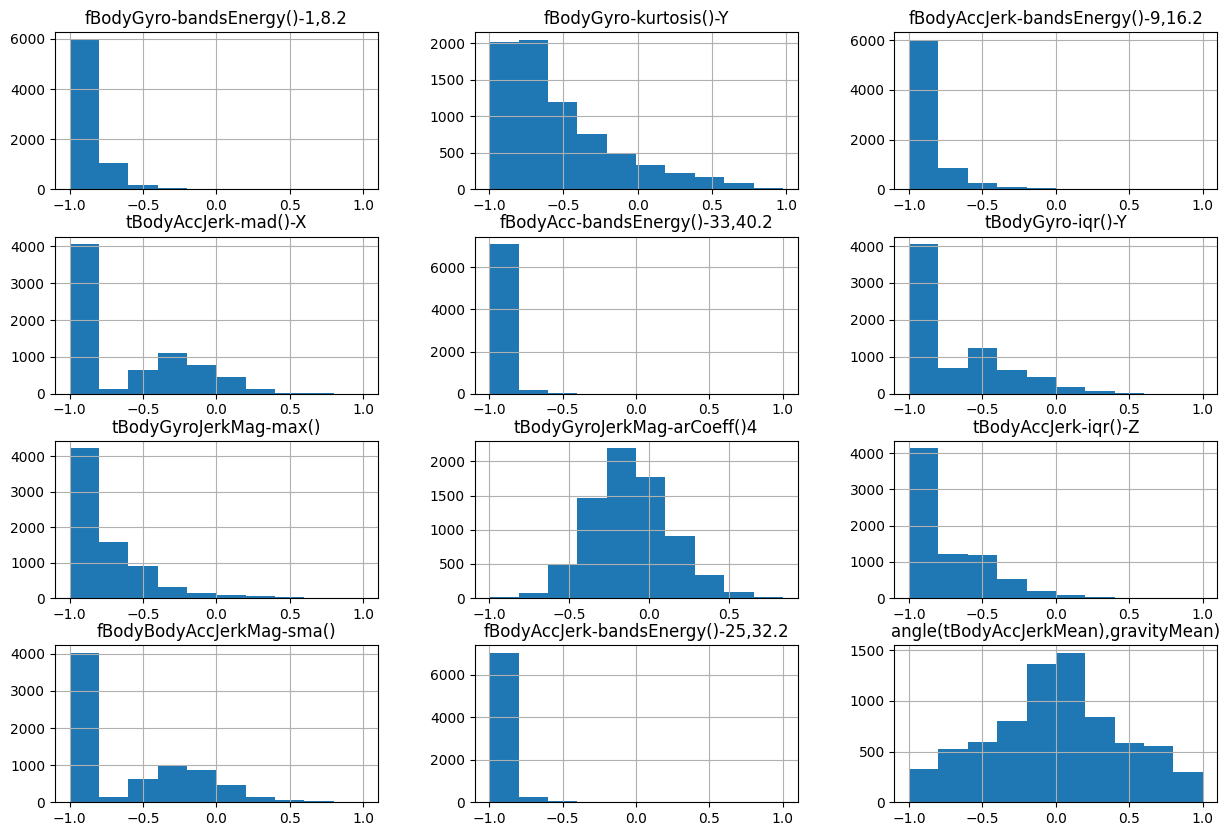

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Sélectionner aléatoirement 10 colonnes numériques
subset = train.select_dtypes(include=['number']).sample(n=12, axis=1, random_state=42)

# Tracer les histogrammes
subset.hist(bins=10, figsize=(15, 10))
plt.show()


In [ ]:
print(train["subject"].unique())  # Affiche les valeurs distinctes de la variable subject


[ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]


In [ ]:
print(train["subject"].value_counts())  # Affiche le nombre d'occurrences de chaque valeur


subject
25    409
21    408
26    392
30    383
28    382
27    376
23    372
17    368
16    366
19    360
1     347
29    344
3     341
15    328
6     325
14    323
22    321
11    316
7     308
5     302
8     281
Name: count, dtype: int64


**la variable subject n'est pas indispensable car elle n'a pas d'effet sur l'accuracy.De plus pour que le modèle soit généralisable à toute personne, il ne doit pas dépendre de subject**

In [ ]:
# la variable subject n'est pas indispensable car elle n'a pas d'effet sur l'accuracy.De plus pour que le modèle soit généralisable à toute personne, il ne doit pas dépendre de subject
train_set =  train.drop("subject", axis=1)

**Séparation de la variable cible Activity avec la variable explicative Activity**

In [ ]:
train_data = train_set.drop("Activity", axis=1)
train_labels = train_set["Activity"].copy()

In [ ]:
#Visualisation des variables explicatives sans la variable subject
train_data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892


In [ ]:
#Affichage des classes de la variable Activity
train_labels.value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


**Utilisation de simpleImputer pour éviter les valeurs manquantes**

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")

In [ ]:
imputer.fit(train_data)

SimpleImputer(strategy='median')

In [ ]:
#Application de Imputer sur toutes la variables numériques pour eviter des valeurs manquantes
imputer.statistics_

array([ 2.77193355e-01, -1.72191435e-02, -1.08676250e-01, -9.46196395e-01,
       -8.51896640e-01, -8.59364595e-01, -9.50709140e-01, -8.57328375e-01,
       -8.57142890e-01, -8.81637305e-01, -4.79677410e-01, -7.36515570e-01,
        7.92060065e-01,  6.27736525e-01,  7.78059410e-01, -8.85460945e-01,
       -9.98046230e-01, -9.94065030e-01, -9.85545630e-01, -9.57859360e-01,
       -8.96093265e-01, -8.64515050e-01, -7.33689755e-02, -1.36792775e-01,
       -1.48888680e-01, -1.29392570e-01,  7.00729385e-02, -1.90008810e-02,
        1.34148595e-01, -4.07103875e-02,  1.17479770e-02,  1.68444095e-01,
       -2.24475890e-02,  2.90437590e-02,  3.26577075e-03,  4.94318595e-02,
       -8.19403680e-02, -1.63727750e-01, -1.89672690e-01,  1.47481965e-01,
        9.19512530e-01, -1.43563995e-01,  2.64101460e-02, -9.81907970e-01,
       -9.76307260e-01, -9.66165855e-01, -9.82637585e-01, -9.77259360e-01,
       -9.67313545e-01,  8.57334850e-01, -1.51599465e-01,  3.68113230e-02,
        9.26692630e-01, -

**Encodage de la variable cible Activity avec l'encodeur LabelEncoder**

In [ ]:
#Voyons d'abord les différentes classes de la colonnes Activity
train_labels.value_counts()

,count
Activity,
LAYING,1407
STANDING,1374
SITTING,1286
WALKING,1226
WALKING_UPSTAIRS,1073
WALKING_DOWNSTAIRS,986


In [ ]:
train_labels.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7352 entries, 0 to 7351
Series name: Activity
Non-Null Count  Dtype 
--------------  ----- 
7352 non-null   object
dtypes: object(1)
memory usage: 57.6+ KB


**Encodage des classes de la cible Activity:** WALKING : 0, STANDING :1,
LAYING:2, WALKING_UPSTAIRS :3, SITTING :4, WALKING_DOWNSTAIRS :5

In [ ]:
#Encodage des classes
from sklearn.preprocessing import LabelEncoder

# Liste des classes
classes = ['WALKING', 'STANDING', 'LAYING', 'WALKING_UPSTAIRS', 'SITTING', 'WALKING_DOWNSTAIRS']

# Création du LabelEncoder
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(classes)

# Encodage des labels
train_labels_encoded = label_encoder.transform(train_labels)

# Nombre d'occurences pour chaque label encodée correspondant
train_labels_encoded_series = pd.Series(train_labels_encoded)
print(train_labels_encoded_series.value_counts())



2    1407
1    1374
4    1286
0    1226
3    1073
5     986
Name: count, dtype: int64


In [ ]:
train_labels_encoded_series.info()

<class 'pandas.core.series.Series'>
RangeIndex: 7352 entries, 0 to 7351
Series name: None
Non-Null Count  Dtype
--------------  -----
7352 non-null   int64
dtypes: int64(1)
memory usage: 57.6 KB


**Création du pipeline pour les variables explication**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

my_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy="median")),
    ('std_scaler', StandardScaler())
    ])


train_data_preparee = my_pipeline.fit_transform(train_data)


In [ ]:
train_data_preparee

array([[ 0.20064157, -0.0636826 , -0.41962845, ..., -0.68721921,
         0.40794614, -0.00756789],
       [ 0.05594788,  0.03148567, -0.25390836, ..., -0.694138  ,
         0.40911698,  0.00787517],
       [ 0.07351535, -0.04341648, -0.07629468, ..., -0.702239  ,
         0.4102883 ,  0.02650234],
       ...,
       [-0.01566765,  0.0167814 ,  1.13222107, ..., -0.56584847,
         0.64059683,  0.34870928],
       [ 0.21586648, -0.02812252, -0.86770988, ..., -0.57766781,
         0.63147758,  0.29327564],
       [ 1.09620157,  0.12919873, -1.67268082, ..., -0.57392691,
         0.63274259,  0.33396081]])

# Création du modèle PMC

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import EarlyStopping
import random
from keras.layers import Dropout

# Fixer la graine aléatoire pour une reproductibilité totale
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Définition de l'architecture du PMC
model = keras.Sequential([
    keras.layers.InputLayer(input_shape=(561,)),
    keras.layers.Dense(128, activation='relu'),
    Dropout(0.25),
    keras.layers.Dense(64, activation='relu'),
    Dropout(0.25),
    keras.layers.Dense(32, activation='relu'),
    Dropout(0.25),
    keras.layers.Dense(6, activation='softmax')  # 6 classes d'activités
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_60 (Dense)                     │ (None, 128)                 │          71,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_45 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_61 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_46 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_47 (Dropout)                 │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 6)                   │             198 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 82,470 (322.15 KB)

 Trainable params: 82,470 (322.15 KB)

 Non-trainable params: 0 (0.00 B)

Compilation du modèle PMC

In [ ]:
# Compilation du modèle
model.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.0003),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping pour éviter le surapprentissage
early_stopping = EarlyStopping(monitor='val_loss', patience=1000, restore_best_weights=True)

Entrainement du modèle

In [ ]:
import time

start_time = time.time()

# Entraînement du modèle
history = model.fit(train_data_preparee, train_labels_encoded,
                    epochs=180,
                    batch_size=128,
                    validation_split=0.05,
                    callbacks=[early_stopping])


end_time = time.time()

# Calcul du temps écoulé en secondes
elapsed_time = end_time - start_time

# Affichage du temps écoulé en secondes
print(f"Temps d'entraînement du PMC : {elapsed_time} secondes")

Epoch 1/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3701 - loss: 1.5316 - val_accuracy: 0.7418 - val_loss: 0.7164
Epoch 2/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6437 - loss: 0.8672 - val_accuracy: 0.8533 - val_loss: 0.4006
Epoch 3/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7361 - loss: 0.6070 - val_accuracy: 0.8940 - val_loss: 0.3037
Epoch 4/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8074 - loss: 0.4791 - val_accuracy: 0.9484 - val_loss: 0.1890
Epoch 5/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8481 - loss: 0.3778 - val_accuracy: 0.9565 - val_loss: 0.1431
Epoch 6/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8775 - loss: 0.3142 - val_accuracy: 0.9674 - val_loss: 0.0983
Epoch 7/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8941 - loss: 0.2749 - val_accuracy: 0.9674 - val_loss: 0.0917
Epoch 8/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9175 - loss: 0.2220 - val_accuracy: 0.9755 - v

Temps d'entraînement du modèle PMC

In [ ]:
# Affichage du temps écoulé en secondes
print(f"Temps d'entraînement du PMC : {elapsed_time} secondes")

Temps d'entraînement du PMC : 52.68593978881836 secondes


**Test du modèle PMC sur le jeu de test:**

Ici, on remarque que le modèle PMC, évalué sur les données de test, atteint une accuracy de **96,20 %**.

In [ ]:
# Evaluation du modèle PMC sur le jeu de test

X_test = test.drop("Activity", axis=1)
X_test_sub = X_test.drop("subject", axis=1)
y_test_labels = test["Activity"].copy()


# Encodage des classes du jeu de test
from sklearn.preprocessing import LabelEncoder

# Liste des classes
classes = ['WALKING', 'STANDING', 'LAYING', 'WALKING_UPSTAIRS', 'SITTING', 'WALKING_DOWNSTAIRS']

# Création du LabelEncoder
label_encoder = LabelEncoder()
label_encoder.classes_ = np.array(classes)

# Encodage des labels
test_labels_encoded = label_encoder.transform(y_test_labels)

In [ ]:
# Préparation des données de test
from sklearn.metrics import classification_report, accuracy_score
X_test_preparee = my_pipeline.transform(X_test_sub)

# Évaluation du modèle PMC sur les données de test
test_loss, test_accuracy = model.evaluate(X_test_preparee, test_labels_encoded)
print(f"Test accuracy du modèle PMC: {test_accuracy * 100:.2f}%")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9565 - loss: 0.2286
Test accuracy du modèle PMC: 96.20%


# Réponse question 2.1.2) Vérification de sur-ajustement ou sous-ajustement du modèle PMC


D'après les courbes d'apprentissage, on remarque que :

Au cours des 25 premières époques, la précision sur les données de validation (val_accuracy) est légèrement supérieure à celle des données d'entraînement (accuracy). Par exemple, val_accuracy atteint 98.91%, tandis que accuracy est de 97.96%. Cependant, au-delà de la 25ᵉ époque, la précision sur les données de validation (val_accuracy) et celle des données d'entraînement (accuracy) deviennent très proches et tendent vers 1, indiquant que le modèle généralise bien.

La perte d'entraînement (loss) diminue rapidement et atteint une valeur très basse (0.0058 à la dernière époque), montrant que le modèle apprend efficacement à minimiser l'erreur sur les données d'entraînement.

La perte de validation (val_loss) suit la même tendance que le Loss. Cela indique qu'il n'y a pas de divergence entre l'apprentissage et la validation.

Donc le modèle ne présente ni sous-ajustement, car il apprend bien les données, ni surajustement, car les performances sur l'entraînement et la validation restent cohérentes.

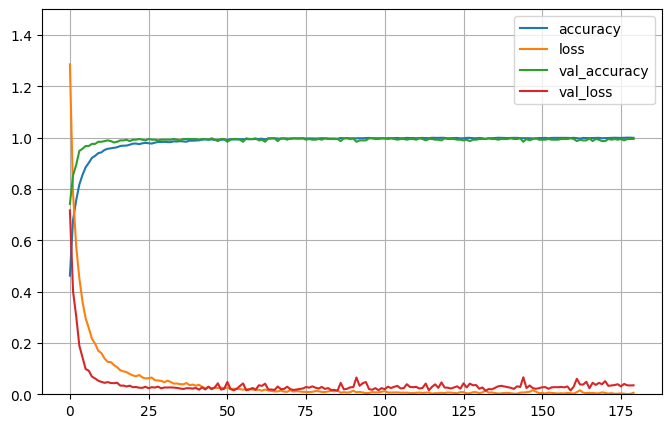

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Tracer l'historique de l'entraînement
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1.5)
plt.show()


# Réponse question 2.1.3) Comparaison du modèle PMC avec XGBOOST obtenu en Devoir1 en termes d'accuracy et de temps d'entrainement.

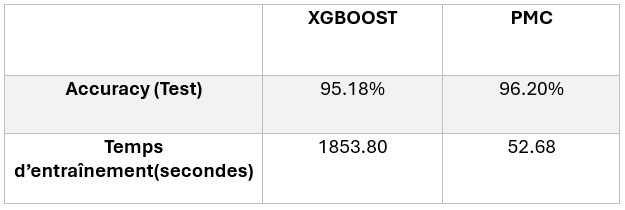

D'après les résultats : le modèle PMC présente une meilleure accuracy (96,20 %) comparé à celle de XGBoost (95,18 %). Cela signifie que PMC fait légèrement moins d'erreurs que XGBoost sur les données de test. De plus, en termes de temps d'entraînement, PMC s'entraîne beaucoup plus rapidement que XGBoost (52,69 secondes contre 1 853,80 secondes).

**Rappel sur les résultats obtenu de XGBOOST dans le devoir1**

Entrainement du modèle XGBOOST par la validation croisée pour k=3

In [ ]:
from xgboost import XGBClassifier

# Initialisation du modèle XGBoost
xgb_clf = XGBClassifier(n_estimators=100, max_depth=10, learning_rate=0.2, random_state=42)

# Entraînement du modèle
xgb_clf.fit(train_data_preparee, train_labels_encoded)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
from sklearn.model_selection import cross_val_predict

# Prédictions en validation croisée
cv_xgb_predictions = cross_val_predict(xgb_clf, train_data_preparee, train_labels_encoded, cv=3)
print(cv_xgb_predictions)

[1 1 1 ... 3 3 3]


**2.4.3) RandomizedSearchCV avec le modèle XGBOOST**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import time

# Définition de la distribution des hyperparamètres
param_dist = {
    "n_estimators": np.arange(100, 500, 50),  # Entre 100 et 500, avec un pas de 50
    "max_depth": [3, 6, 10, 15],  # Profondeur de l'arbre
    "learning_rate": np.linspace(0.01, 0.3, 5),  # Taux d'apprentissage entre 0.01 et 0.3
    "subsample": [0.6, 0.8, 1.0],  # Fraction des échantillons utilisés
    "colsample_bytree": [0.6, 0.8, 1.0],  # Fraction des features utilisées par arbre
    "gamma": [0, 0.1, 0.2, 0.3]  # Régularisation
}

# Initialisation du modèle XGBoost
xgb_clf = XGBClassifier(eval_metric="mlogloss", random_state=42)

# Initialisation de RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=15,  # Nombre de combinaisons aléatoires testées
    cv=3,  # Validation croisée à 3 folds
    scoring="accuracy",  # Évaluation avec l'accuracy
    random_state=42
)

# temps d'entraînement
start_time = time.time()

# Lancer la recherche des meilleurs hyperparamètres
random_search_xgb.fit(train_data_preparee, train_labels_encoded)

end_time = time.time()  # Temps après l'entraînement

# Calculer la durée totale de l'entraînement
training_time = end_time - start_time

print(f"Temps d'entraînement: {training_time:.2f} secondes")


Temps d'entraînement: 1853.80 secondes


In [ ]:
print("Meilleurs hyperparamètres :", random_search_xgb.best_params_)
print("Meilleure précision obtenue :", random_search_xgb.best_score_)

best_xgboost_clf = random_search_xgb.best_estimator_
print("Meilleure modèle obtenu:", best_xgboost_clf)

Meilleurs hyperparamètres : {'subsample': 0.6, 'n_estimators': np.int64(150), 'max_depth': 3, 'learning_rate': np.float64(0.22749999999999998), 'gamma': 0.2, 'colsample_bytree': 0.8}
Meilleure précision obtenue : 0.9211133592563913
Meilleure modèle obtenu: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=np.float64(0.22749999999999998), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(150), n_jobs=No

**2.5.3) Test du meilleur modèle XGBOOST sur le jeu de test**

Le test du meilleur modèle de XGBoost sur les données de test atteint une accuracy de 95.18%

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#Appel my_pipeline sur les données de test
X_test_preparee = my_pipeline.transform(X_test_sub)
final_predictions = best_xgboost_clf.predict(X_test_preparee) #best_xgboost_clf est le meilleur modèle obtenu en utilisant l'hypermaratère RandomizedSearchCV
accuracy = accuracy_score(test_labels_encoded, final_predictions)

#Affichage de l'accuracy
print(f"Accuracy sur les données de test du meilleur modèle XGBOOST : {accuracy:.4f}")

# Affichage des metriques précision, rappel et f1-score
print("Rapport de classification :\n", classification_report(test_labels_encoded, final_predictions))

Accuracy sur les données de test du meilleur modèle XGBOOST : 0.9518
Rapport de classification :
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       496
           1       0.91      0.96      0.94       532
           2       1.00      1.00      1.00       537
           3       0.93      0.93      0.93       471
           4       0.95      0.90      0.92       491
           5       0.98      0.93      0.95       420

    accuracy                           0.95      2947
   macro avg       0.95      0.95      0.95      2947
weighted avg       0.95      0.95      0.95      2947



# Réponse question 2.1.4): Le recours à un réseau de neurones profond peut-il surpasser le modèle obtenu en 2.1.1

Pour répondre à cette question, on ajoute des couches Cachées et testé l'accuracy sur les données de tests.

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import LabelEncoder
from keras.callbacks import EarlyStopping
import random
from keras.layers import Dropout

# Fixer la graine aléatoire pour une reproductibilité totale
seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

# Définition de l'architecture du PMC
model_profond = keras.Sequential([
    keras.layers.InputLayer(input_shape=(561,)),
    keras.layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002)),  # Nouvelle couche ajoutée ici
    keras.layers.Dropout(0.1),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002)),
    keras.layers.Dropout(0.1),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(128, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002)),
    keras.layers.Dropout(0.1),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.002)),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(6, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# Compilation du modèle
model_profond.compile(optimizer=keras.optimizers.AdamW(learning_rate=0.0001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Early stopping pour éviter le surapprentissage
early_stopping = EarlyStopping(monitor='val_loss', patience=1000, restore_best_weights=True)

In [ ]:
import time

start_time = time.time()

# Entraînement du modèle
history = model_profond.fit(train_data_preparee, train_labels_encoded,
                    epochs=180,
                    batch_size=128,
                    validation_split=0.05,
                    callbacks=[early_stopping])


end_time = time.time()

# Calcul du temps écoulé en secondes
elapsed_time = end_time - start_time

# Affichage du temps écoulé en secondes
print(f"Temps d'entraînement du PMC : {elapsed_time} secondes")

Epoch 1/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.3900 - loss: 3.9648 - val_accuracy: 0.6467 - val_loss: 3.5104
Epoch 2/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7759 - loss: 2.9942 - val_accuracy: 0.8397 - val_loss: 3.0306
Epoch 3/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8580 - loss: 2.7754 - val_accuracy: 0.9049 - val_loss: 2.7227
Epoch 4/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8939 - loss: 2.6598 - val_accuracy: 0.9511 - val_loss: 2.5445
Epoch 5/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9235 - loss: 2.5687 - val_accuracy: 0.9620 - val_loss: 2.4559
Epoch 6/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9321 - loss: 2.5037 - val_accuracy: 0.9701 - val_loss: 2.3894
Epoch 7/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9453 - loss: 2.4445 - val_accuracy: 0.9783 - val_loss: 2.3396
Epoch 8/180
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9497 - loss: 2.3975 - val_accuracy: 0.

In [ ]:
# Préparation des données de test
from sklearn.metrics import classification_report, accuracy_score
X_test_preparee = my_pipeline.transform(X_test_sub)

# Évaluation du modèle PMC sur les données de test
test_loss, test_accuracy = model_profond.evaluate(X_test_preparee, test_labels_encoded)
print(f"Test accuracy du modèle PMC: {test_accuracy * 100:.2f}%")

93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9532 - loss: 0.2750
Test accuracy du modèle PMC: 95.05%
